In [29]:
%matplotlib inline

from collections.abc import Callable

import numpy as np
import torch
from torch import nn
from d2l import torch as d2l

In [30]:
# Optimization Trace

ScalarFunction = Callable[
    [torch.Tensor],
    torch.Tensor,
]

def show_trace(
    results: list[float],
    function: ScalarFunction,
) -> None:
    results_tensor = torch.tensor(
        results
    )

    bound = results_tensor.abs().max().item()

    x_line = torch.arange(
        -bound,
        bound,
        0.01,
    )

    d2l.plot(
        [
            x_line,
            results_tensor,
        ],
        [
            function(x_line),
            function(results_tensor),
        ],
        xlabel="x",
        ylabel="f(x)",
        fmts=[
            "-",
            "-o",
        ],
    )

In [31]:
# Newton's Method

def newton(
    gradient: ScalarFunction,
    hessian: ScalarFunction,
    learning_rate: float = 1.0,
    num_steps: int = 10,
) -> list[float]:
    
    x = torch.tensor(
        10.0
    )
    
    results = [
        x.item()
    ]
    
    for _ in range(num_steps):
        x = (
            x 
            - learning_rate
            * gradient(x)
            / hessian(x) 
        )
        
        results.append(
            x.item()
        )
        
    print(
        f"step {num_steps}, "
        f"x: {x.item():f}"
    )
    
    return results

step 10, x: 0.000000


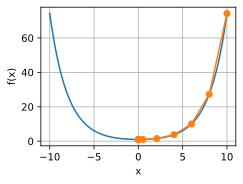

In [32]:
# Convex Function

convex_c = torch.tensor(
    0.5
)

def convex_objective(
    x: torch.Tensor,
) -> torch.Tensor:
    return torch.cosh(
        convex_c * x
    )
    
    
def convex_gradient(
    x: torch.Tensor,
) -> torch.Tensor:
    return (
        convex_c
        * torch.sinh(convex_c * x)
    )
    
    
def convex_hessian(
    x: torch.Tensor,
) -> torch.Tensor:
    return (
        convex_c.pow(2)
        * torch.cosh(convex_c * x)
    )
    
    
convex_results = newton(
    gradient=convex_gradient,
    hessian=convex_hessian,
)

show_trace(
    convex_results,
    convex_objective,
)

step 10, x: 26.834133


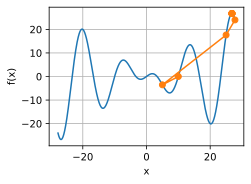

In [33]:
# Nonconvex Function

nonconvex_c = torch.tensor(
    0.15 * np.pi
)

def nonconvex_objective(
    x: torch.Tensor,
) -> torch.Tensor:
    return (
        x 
        * torch.cos(nonconvex_c * x)
    )
    
def nonconvex_gradient(
    x: torch.Tensor,
) -> torch.Tensor:
    return (
        torch.cos(nonconvex_c * x)
        - nonconvex_c
        * x
        * torch.sin(nonconvex_c * x)
    )
    
def nonconvex_hessian(
    x: torch.Tensor,
) -> torch.Tensor:
    return (
        -2
        * nonconvex_c
        * torch.sin(nonconvex_c * x)
        - x
        * nonconvex_c**2
        * torch.cos(nonconvex_c * x)
    )
 
    
unstable_results = newton(
    gradient=nonconvex_gradient,
    hessian=nonconvex_hessian,
)

show_trace(
    unstable_results,
    nonconvex_objective,
)

step 10, x: 7.506131


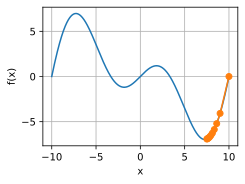

In [35]:
# Damped Newton's Method

damped_results = newton(
    gradient=nonconvex_gradient,
    hessian=nonconvex_hessian,
    learning_rate=0.2
)

show_trace(
    damped_results,
    nonconvex_objective,
)